#### 이상치제거추가_데이터전처리_로지스틱분류실험 251103

- 251029의 실험결과가 너무 안좋아서 추가 데이터 전처리 필요할듯

- 이상치 제거 방법: IQR, One-Class SVM, Local Outlier Factor, Isolation Forest 등 여러가지가 있는듯 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("./credit_risk_dataset.csv") 
df.head() 

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.shape

(32581, 12)

- loan_int_rate 변수 제거 

In [4]:
corr_x = df.select_dtypes(['float', 'int']).corr()

In [5]:
df = df.drop(['loan_int_rate'], axis=1) 
df.head() 

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,1,0.55,Y,4


#### 결측치 확인 및 채워넣기 

In [6]:
df.isnull().sum()

person_age                      0
person_income                   0
person_home_ownership           0
person_emp_length             895
loan_intent                     0
loan_grade                      0
loan_amnt                       0
loan_status                     0
loan_percent_income             0
cb_person_default_on_file       0
cb_person_cred_hist_length      0
dtype: int64

In [7]:
df = df.fillna(0)
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [8]:
df.select_dtypes('object').head()

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
0,RENT,PERSONAL,D,Y
1,OWN,EDUCATION,B,N
2,MORTGAGE,MEDICAL,C,N
3,RENT,MEDICAL,C,N
4,RENT,MEDICAL,C,Y


#### 이상치 box plot 시각화 

In [9]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_status', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length'],
      dtype='object')

In [10]:
df.select_dtypes('number').head()

,person_age,person_income,person_emp_length,loan_amnt,loan_status,loan_percent_income,cb_person_cred_hist_length
0,22,59000,123.0,35000,1,0.59,3
1,21,9600,5.0,1000,0,0.10,2
2,25,9600,1.0,5500,1,0.57,3
3,23,65500,4.0,35000,1,0.53,2
4,24,54400,8.0,35000,1,0.55,4


In [11]:
now_columns = list(df.select_dtypes('number').columns)
now_columns.remove('loan_status')
now_columns

['person_age',
 'person_income',
 'person_emp_length',
 'loan_amnt',
 'loan_percent_income',
 'cb_person_cred_hist_length']

In [12]:
print("loan_status는 0,1인 변수이므로 이것을 제외하고 시각화.")

loan_status는 0,1인 변수이므로 이것을 제외하고 시각화.


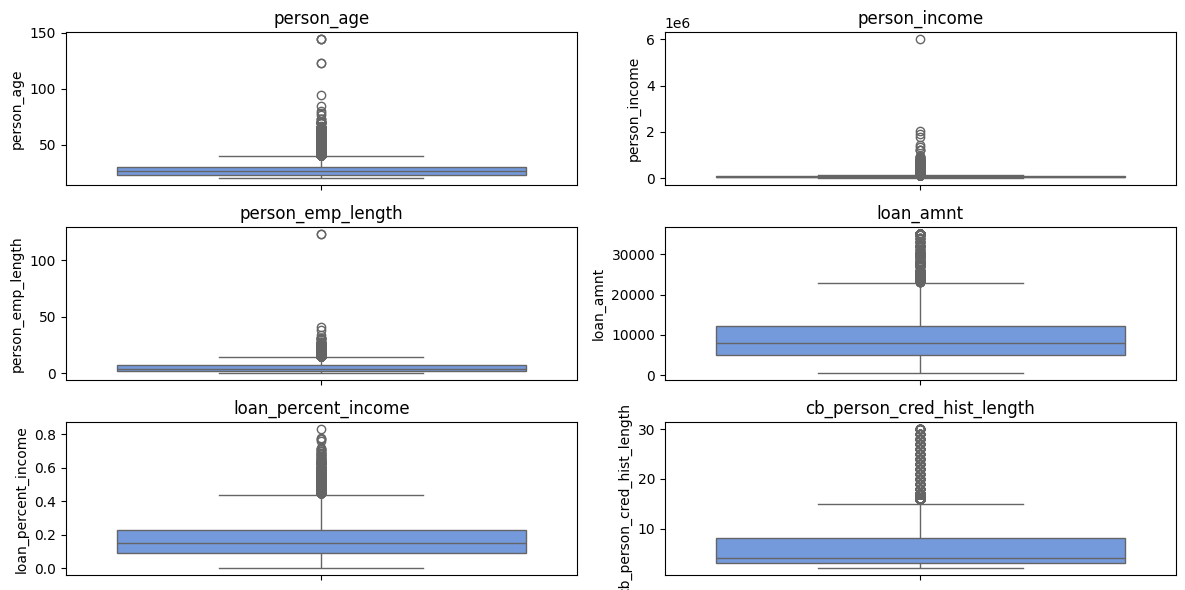

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(12, 6))
axes = axes.flatten()

for i, col in enumerate(now_columns):
    sns.boxplot(data=df, y = col, ax=axes[i], color='cornflowerblue')
    axes[i].set_title(f'{col}')

plt.tight_layout()
plt.show()

In [14]:
print("위 6개 컬럼들은 다 이상치가 있어보이므로 제거 필요. ")

위 6개 컬럼들은 다 이상치가 있어보이므로 제거 필요. 


#### 값 파악 
- 이상치의 보수적인 제거 

In [15]:
# person_age
print(df['person_age'].max())
print(df[df['person_age'] > 100].shape[0])
print(df[df['person_age'] > 100].loan_grade.unique())  # 데이터 많은쪽 클래스라 제거해도 될듯 
print("B,C는 데이터 많은쪽 클래스라 100세 이상인 데이터 제거해도 될듯. ")

144
5
['C' 'B']
B,C는 데이터 많은쪽 클래스라 100세 이상인 데이터 제거해도 될듯. 


In [16]:
# person_income 
print(df['person_income'].max())
print(df['person_income'].sort_values(ascending=False))
print(df[df['person_income'] == 6000000].loan_grade.unique())
print("C는 데이터 많은쪽 클래스라 데이터 제거해도 될듯. ")

6000000
32297    6000000
30049    2039784
32546    1900000
32497    1782000
31924    1440000
          ...   
15960       4800
15963       4200
27896       4200
15964       4080
31930       4000
Name: person_income, Length: 32581, dtype: int64
['C']
C는 데이터 많은쪽 클래스라 데이터 제거해도 될듯. 


In [17]:
# person_emp_length
print(df['person_emp_length'].max())
print(df['person_emp_length'].sort_values(ascending=False))
print(df[df['person_emp_length'] == 123].loan_grade.unique())
print("D클래스를 포함하고 있긴 하지만 고용기간이 123년은 너무 outlier라서 데이터 제거.")

123.0
210      123.0
0        123.0
32355     41.0
32515     38.0
32428     34.0
         ...  
11548      0.0
11544      0.0
11567      0.0
11566      0.0
32528      0.0
Name: person_emp_length, Length: 32581, dtype: float64
['D' 'A']
D클래스를 포함하고 있긴 하지만 고용기간이 123년은 너무 outlier라서 데이터 제거.


In [18]:
# person_income
print(df['person_income'].max())
print(df['person_income'].sort_values(ascending=False))
df[df['person_income'] == 2039784]
print("income이 높고, venture 투자를 해서 loan_grade가 C인듯. 데이터 안빼고 일단 유지.")

6000000
32297    6000000
30049    2039784
32546    1900000
32497    1782000
31924    1440000
          ...   
15960       4800
15963       4200
27896       4200
15964       4080
31930       4000
Name: person_income, Length: 32581, dtype: int64
income이 높고, venture 투자를 해서 loan_grade가 C인듯. 데이터 안빼고 일단 유지.


#### 데이터 제거

In [19]:
print(df.shape)
df = df[df['person_age'] <= 100]
print(df.shape)  # 제거 후 데이터 개수 

(32581, 11)
(32576, 11)


In [20]:
print(df.shape) 
df = df[df['person_income'] != 6000000]
print(df.shape)  # 제거 후 데이터 개수 
print('person_age에서 제거된듯')

(32576, 11)
(32576, 11)
person_age에서 제거된듯


In [21]:
print(df[df['person_emp_length'] == 123])
print('person_age가 21,22인데 고용기간이 123년이라니 잘못된 데이터 같음')

     person_age  person_income person_home_ownership  person_emp_length  \
0            22          59000                  RENT              123.0   
210          21         192000              MORTGAGE              123.0   

    loan_intent loan_grade  loan_amnt  loan_status  loan_percent_income  \
0      PERSONAL          D      35000            1                 0.59   
210     VENTURE          A      20000            0                 0.10   

    cb_person_default_on_file  cb_person_cred_hist_length  
0                           Y                           3  
210                         N                           4  
person_age가 21,22인데 고용기간이 123년이라니 잘못된 데이터 같음


In [22]:
print(df.shape) 
df = df[df['person_emp_length'] != 123]
print(df.shape)  # 제거 후 데이터 개수 

(32576, 11)
(32574, 11)


#### 데이터 나누기 

In [23]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_status', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length'],
      dtype='object')

In [24]:
features = list(df.columns)
features.remove('loan_grade')

X = df[features]
y = df['loan_grade']

#### 명목형변수 변경   
- 우선은 one-hot-encoding으로 / label encoding도 고려해보기 

In [25]:
X.select_dtypes('object').head()

,person_home_ownership,loan_intent,cb_person_default_on_file
1,OWN,EDUCATION,N
2,MORTGAGE,MEDICAL,N
3,RENT,MEDICAL,N
4,RENT,MEDICAL,Y
5,OWN,VENTURE,N


In [27]:
# label encoding
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
X['person_home_ownership'] = encoder.fit_transform(X['person_home_ownership'])
X['loan_intent'] = encoder.fit_transform(X['loan_intent'])
X['cb_person_default_on_file'] = encoder.fit_transform(X['cb_person_default_on_file'])

In [28]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32574 entries, 1 to 32580
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32574 non-null  int64  
 1   person_income               32574 non-null  int64  
 2   person_home_ownership       32574 non-null  int64  
 3   person_emp_length           32574 non-null  float64
 4   loan_intent                 32574 non-null  int64  
 5   loan_amnt                   32574 non-null  int64  
 6   loan_status                 32574 non-null  int64  
 7   loan_percent_income         32574 non-null  float64
 8   cb_person_default_on_file   32574 non-null  int64  
 9   cb_person_cred_hist_length  32574 non-null  int64  
dtypes: float64(2), int64(8)
memory usage: 2.7 MB


In [29]:
# 트레이닝/테스트 데이터 분할 
from sklearn.model_selection import train_test_split
X_tn, X_te, y_tn, y_te = train_test_split(X, y, random_state=0, stratify=y)

In [30]:
# 데이터 표준화
from sklearn.preprocessing import StandardScaler 
std_scale = StandardScaler()
std_scale.fit(X_tn)
X_tn_std = std_scale.transform(X_tn)
X_te_std = std_scale.transform(X_te)

In [31]:
y_tn.shape

(24430,)

In [32]:
df_tmp = pd.concat([pd.DataFrame(X_tn_std, columns=X.columns), pd.Series(y_tn)], axis=1)
df_tmp.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_amnt,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_grade
0,-0.121577,0.059186,0.922664,1.566162,1.420119,-1.116323,-0.529336,-1.217444,-0.462181,0.531760,NaN
1,-0.926924,-0.668859,0.922664,0.334413,0.267913,-0.066463,-0.529336,1.212731,-0.462181,-0.940436,NaN
2,-0.604785,-0.108824,-1.171547,1.073462,-0.308190,-1.274197,-0.529336,-1.310913,-0.462181,-0.940436,C
3,-0.443715,-0.512050,0.922664,-0.650987,-0.884294,-0.879512,-0.529336,-0.656635,-0.462181,-0.449704,C
4,0.039493,0.115190,0.922664,0.334413,0.267913,0.857099,-0.529336,0.371516,-0.462181,0.041028,C


In [33]:
df_tmp.shape

(30580, 11)

In [34]:
x_cols = list(df.columns)
x_cols.remove('loan_grade')

In [35]:
len(x_cols)

10

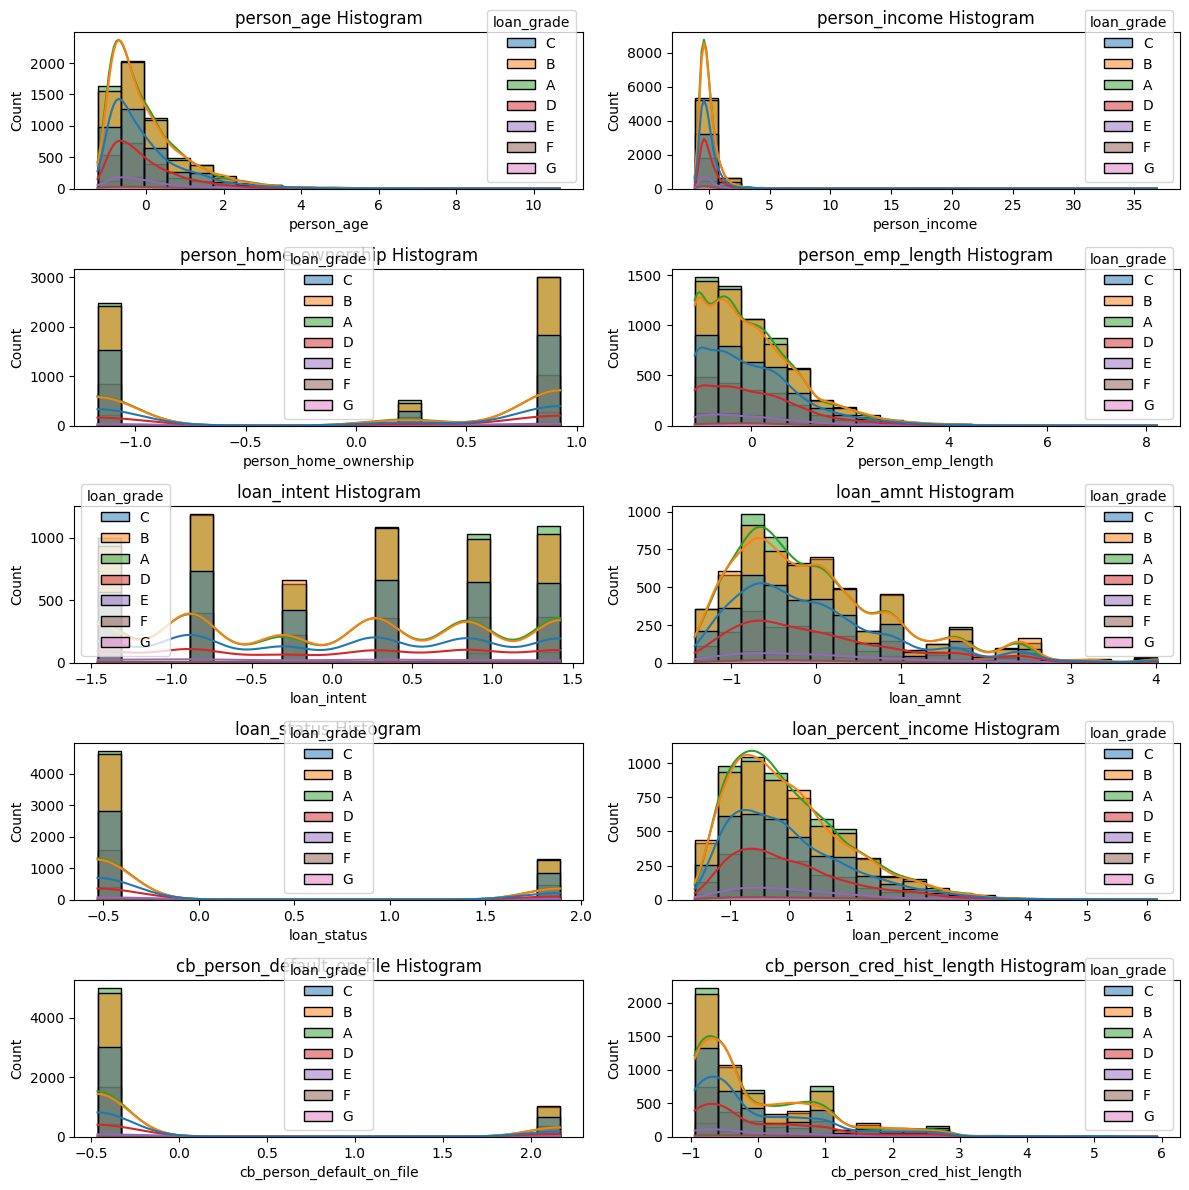

In [36]:
fig, axes = plt.subplots(5, 2, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(x_cols):
    sns.histplot(data=df_tmp, x=col, hue='loan_grade', bins=20, kde=True, ax=axes[i], color='cornflowerblue')
    axes[i].set_title(f'{col} Histogram')

plt.tight_layout()
plt.show()

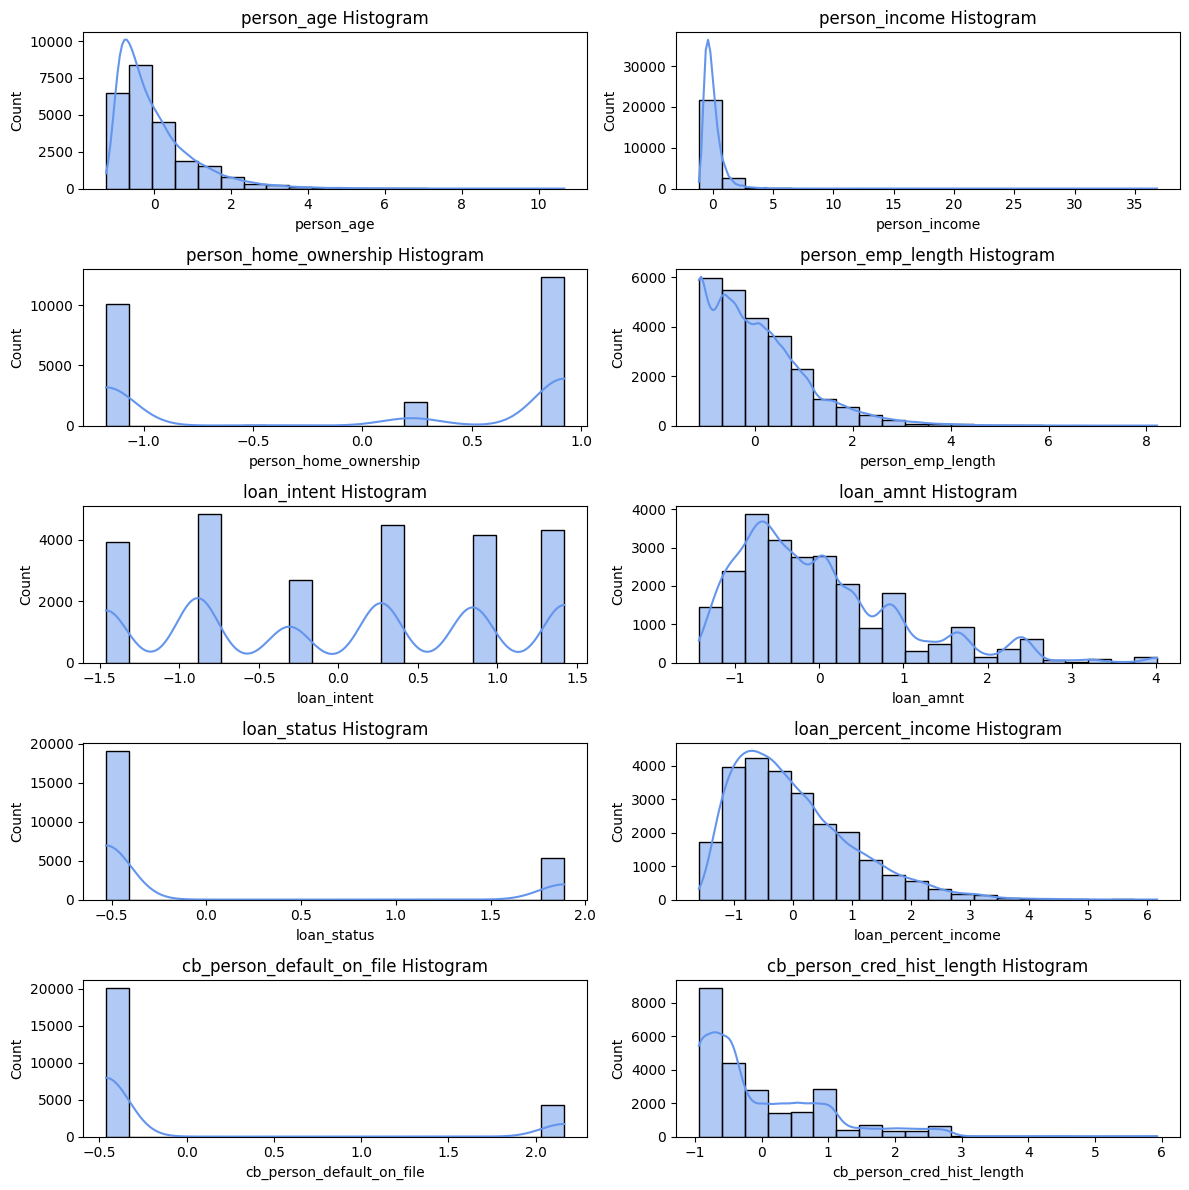

In [47]:
fig, axes = plt.subplots(5, 2, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(x_cols):
    sns.histplot(data=df_tmp, x=col, bins=20, kde=True, ax=axes[i], color='cornflowerblue')
    axes[i].set_title(f'{col} Histogram')

plt.tight_layout()
plt.show()

#### 로지스틱 모델 돌려보기 

In [37]:
# 로지스틱 회귀분석 (L2 제약식 적용)
from sklearn.linear_model import LogisticRegression
clf_logi_l2 = LogisticRegression(penalty='l2')
clf_logi_l2.fit(X_tn_std, y_tn)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [38]:
# 로지스틱 회귀분석 모형 (L2 제약식 적용) 추정 계수
print(clf_logi_l2.coef_)
print(clf_logi_l2.intercept_)

[[ 0.0354417   0.16523901 -0.1596726   0.03178894 -0.10914764 -0.74725024
  -0.99042482  0.48007398 -2.63393349 -0.07665431]
 [ 0.01614964  0.12866167  0.11761122 -0.01152758 -0.08396132 -0.39014788
  -0.81030038  0.40367326 -2.61379891 -0.04512142]
 [ 0.02945048  0.09018484  0.14997896 -0.04814715 -0.13874363 -0.4300777
  -0.6414134   0.30471864  1.04862812 -0.01379428]
 [ 0.01330175 -0.10873275  0.10206051  0.02867197 -0.02339185  0.094096
   0.20516917 -0.21016872  1.07740019 -0.01498934]
 [ 0.12148969  0.01739434  0.08977961 -0.08782137  0.01729822  0.26823939
   0.32785901 -0.23303843  1.0245924  -0.13265484]
 [ 0.10090922 -0.12860841 -0.09260872 -0.14450504 -0.02666018  0.53311887
   0.42867688 -0.3520489   1.03065044 -0.03768207]
 [-0.31674249 -0.1641387  -0.20714897  0.23154022  0.3646064   0.67202156
   1.48043354 -0.39320984  1.06646125  0.32089626]]
[ 1.64946977  1.70456214  2.22451832  1.2950454  -0.16908813 -1.77684194
 -4.92766555]


In [39]:
# 예측
pred_logistic = clf_logi_l2.predict(X_te_std)
print(pred_logistic)

['B' 'B' 'A' ... 'D' 'C' 'A']


In [40]:
# confusion matrix 확인
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_te, pred_logistic)
print(conf_matrix)

[[1640 1030    0   24    0    0    0]
 [1204 1361    0   47    0    0    0]
 [ 363  417  679  155    0    0    0]
 [ 141  251  208  306    1    0    0]
 [  25   78   48   90    0    0    0]
 [   3   25    9   22    1    0    0]
 [   1    1    0   14    0    0    0]]


['A', 'B', 'C', 'D', 'E', 'F', 'G']


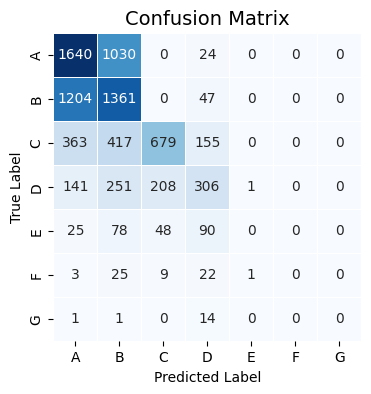

In [41]:
labels = sorted(df['loan_grade'].unique())
print(labels)

plt.figure(figsize=(4,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels, 
            linewidths=0.5, cbar=False, square=True)

plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [42]:
# 분류 레포트 확인
from sklearn.metrics import classification_report
class_report = classification_report(y_te, pred_logistic)
print(class_report)

              precision    recall  f1-score   support

           A       0.49      0.61      0.54      2694
           B       0.43      0.52      0.47      2612
           C       0.72      0.42      0.53      1614
           D       0.47      0.34      0.39       907
           E       0.00      0.00      0.00       241
           F       0.00      0.00      0.00        60
           G       0.00      0.00      0.00        16

    accuracy                           0.49      8144
   macro avg       0.30      0.27      0.28      8144
weighted avg       0.49      0.49      0.48      8144



In [43]:
print("직접 값을 보고 이상치를 제거했는데, 성능이 오히려 소폭 낮아짐...")

직접 값을 보고 이상치를 제거했는데, 성능이 오히려 소폭 낮아짐...
